# 00 — MASTER REPORT: one notebook to verify everything

This notebook calls **every module in the repo** and plots everything in one place. Re-running it = re-validating the whole stack on fresh data.

```bash
.venv/bin/python tools/build_master.py   # rebuild + execute all notebooks
```

| Section | Source module | What it validates |
|---|---|---|
| 1. Health check | `src/connectors/*` | all 6 connectors respond |
| 2. Universe + quality | `market_data.py` | clean OHLCV data |
| 3. EDGAR + Polymarket | `edgar.py`, `polymarket.py` | SpaceX filings, live odds |
| 4. Signal quality | `research/signal_quality.py` | source grading + cleaned attention data |
| 5. Correlations | `risk/metrics.py` | structure vs current regime |
| 6. Distributional validation | `research/dist_validation.py` | the MC's fat tails are empirical |
| 7. Lockup event study | `research/lockup_study.py` | the August thesis against history |
| 8. Monte Carlo | `risk/montecarlo.py` | plan VaR/ES + sensitivity |
| 9. Verdict | — | operational synthesis |

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()

## 1. Connector health check

Each source is tested with a minimal call. A FAIL here means nothing downstream can be trusted.

In [2]:
import time
checks = []
def check(name, fn):
    t0 = time.time()
    try:
        out = fn(); checks.append({"connector": name, "status": "OK", "ms": int((time.time()-t0)*1000), "detail": out})
    except Exception as e:
        checks.append({"connector": name, "status": "FAIL", "ms": int((time.time()-t0)*1000), "detail": str(e)[:80]})

from src.connectors.market_data import get_ohlcv, get_universe
from src.connectors.edgar import recent_filings, form4_watch
from src.connectors.polymarket import search_markets
from src.connectors.fred import risk_free_rate
from src.connectors.hackernews import daily_attention
from src.connectors.wikipedia import pageviews

check("market_data (yfinance/stooq)", lambda: f"GOOGL last close {get_ohlcv('GOOGL','6mo').Close.iloc[-1]:.2f}")
check("EDGAR (official SEC)", lambda: f"{len(recent_filings(limit=10))} SpaceX filings")
check("Polymarket Gamma", lambda: f"{len(search_markets('spacex'))} live markets")
check("FRED (^IRX fallback)", lambda: f"3M T-bill {risk_free_rate():.2%}")
check("Hacker News (Algolia)", lambda: f"{int(daily_attention('spacex ipo', days=30)['stories'].sum())} stories/30d")
check("Wikipedia pageviews", lambda: f"{pageviews('SpaceX', days=30).mean():,.0f} views/day")
hc = pd.DataFrame(checks)
assert (hc.status == "OK").all(), f"CONNECTOR DOWN:\n{hc[hc.status!='OK']}"
hc

,connector,status,ms,detail
0,market_data (yfinance/stooq),OK,20,GOOGL last close 364.26
1,EDGAR (official SEC),OK,254,10 SpaceX filings
2,Polymarket Gamma,OK,125,12 live markets
3,FRED (^IRX fallback),OK,30859,3M T-bill 3.63%
4,Hacker News (Algolia),OK,1233,126 stories/30d
5,Wikipedia pageviews,OK,2,"5,324 views/day"


## 2. Universe with quality gate

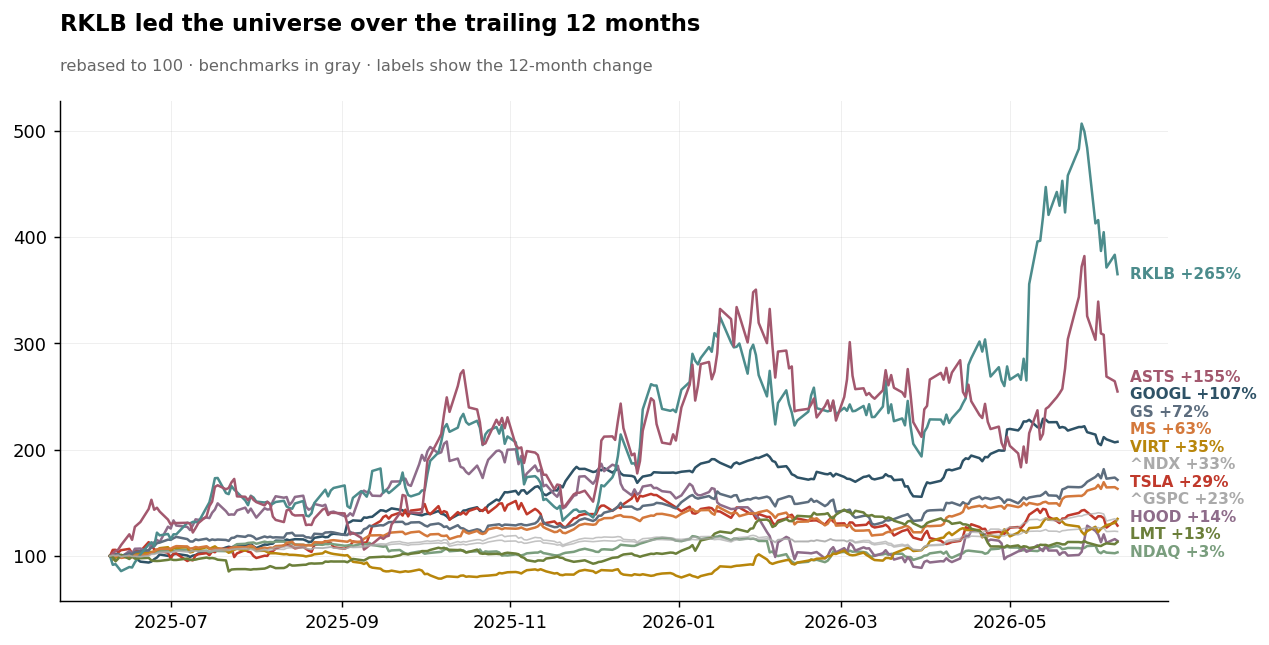

,rows,first,last,missing_bdays,warnings
ticker,,,,,
GOOGL,500,2024-06-11,2026-06-09,21,[]
TSLA,500,2024-06-11,2026-06-09,21,[]
NDAQ,500,2024-06-11,2026-06-09,21,[]
HOOD,500,2024-06-11,2026-06-09,21,[]
VIRT,500,2024-06-11,2026-06-09,21,[]
GS,500,2024-06-11,2026-06-09,21,[]
MS,500,2024-06-11,2026-06-09,21,[]
RKLB,501,2024-06-11,2026-06-10,21,[]
ASTS,501,2024-06-11,2026-06-10,21,[jump >50% on 2024-08-15 (verify: real move or...


In [3]:
UNIVERSE = ['GOOGL', 'TSLA', 'NDAQ', 'HOOD', 'VIRT', 'GS', 'MS', 'RKLB', 'ASTS', 'LMT', '^GSPC', '^NDX', '^VIX']
prices, reports = get_universe(UNIVERSE, period="2y")
qa = pd.DataFrame(reports).set_index("ticker")
assert qa["issues"].map(len).sum() == 0, "QUALITY FAIL"
prices.to_parquet("../data/universe_prices.parquet")
norm_px = prices.drop(columns=["^VIX"]).dropna().tail(252)
norm = 100 * norm_px / norm_px.iloc[0]
fig, ax = plt.subplots(figsize=(11, 5))
for c in norm.columns:
    b = c.startswith("^")
    ax.plot(norm.index, norm[c], lw=0.9 if b else 1.4, color="#AAAAAA" if b else None, alpha=0.7 if b else 1)
fmt = {c: f"{c} {norm[c].dropna().iloc[-1]-100:+.0f}%" for c in norm.columns}
direct_label_lines(ax, norm, fmt=fmt)
headline(ax, f"{max(norm.columns, key=lambda c: norm[c].dropna().iloc[-1])} led the universe over the trailing 12 months",
         "rebased to 100 · benchmarks in gray · labels show the 12-month change")
plt.show()
qa[["rows", "first", "last", "missing_bdays", "warnings"]]

## 3. SEC EDGAR + Polymarket, live

From August, `form4_watch()` is the insider-sales monitor (public by law within 2 business days).

In [4]:
print(f"SpaceX Form 3/4/144 to date: {len(form4_watch())} (expected from August, post-lockup)")
pd.DataFrame(recent_filings(limit=8))

SpaceX Form 3/4/144 to date: 0 (expected from August, post-lockup)


,form,date,url
0,CERT,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
1,8-A12B,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
2,8-A12B,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
3,CERT,2026-06-10,https://www.sec.gov/Archives/edgar/data/118141...
4,FWP,2026-06-09,https://www.sec.gov/Archives/edgar/data/118141...
5,FWP,2026-06-08,https://www.sec.gov/Archives/edgar/data/118141...
6,FWP,2026-06-05,https://www.sec.gov/Archives/edgar/data/118141...
7,FWP,2026-06-05,https://www.sec.gov/Archives/edgar/data/118141...


In [5]:
pm = pd.DataFrame([{"market": m["market"], **{f"P({k})": v for k, v in m["outcomes"].items()}, "volume_usd": int(m["volume"])} for m in search_markets("spacex", limit=8)])
pm

,market,P(Yes),P(No),volume_usd
0,SpaceX IPO closing market cap above $3T?,0.065,0.935,1871019
1,SpaceX IPO closing market cap above $2T?,0.625,0.375,1126717
2,SpaceX IPO closing market cap above $1.8T?,0.825,0.175,1031437
3,Will SpaceX's market cap be between $2.5T and ...,0.163,0.837,912938
4,"Will SpaceX IPO by May 31, 2026?",0.000,1.000,906312
5,SpaceX IPO closing market cap above $2.4T?,0.235,0.765,889423
6,SpaceX IPO closing market cap above $1T?,0.993,0.007,754203
7,Will SpaceX's market cap be greater than $1T a...,0.992,0.008,751047


## 4. Signal quality — grade the sources, clean the data

Rubric: `score = 0.40·skin-in-the-game + 0.25·timeliness + 0.25·verifiability − 0.10·noise`. Full analysis (cleaning pipeline, attention timeline, lead-lag test) in notebook 04.

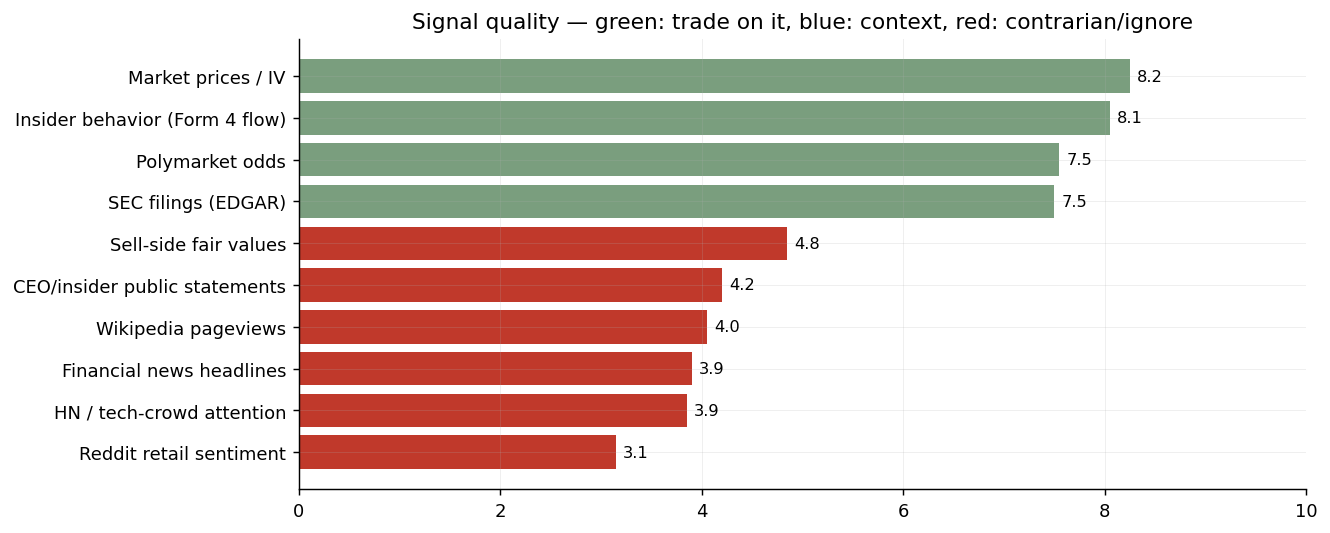

In [6]:
from src.research.signal_quality import ranking_table, clean_series, zscore
rt = ranking_table()
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [PALETTE[2] if s >= 7 else PALETTE[0] if s >= 5 else PALETTE[1] for s in rt["score"]]
ax.barh(rt["source"][::-1], rt["score"][::-1], color=colors[::-1])
for i, s in enumerate(rt["score"][::-1]):
    ax.annotate(f"{s:.1f}", (s, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_title("Signal quality — green: trade on it, blue: context, red: contrarian/ignore")
ax.set_xlim(0, 10)
plt.show()

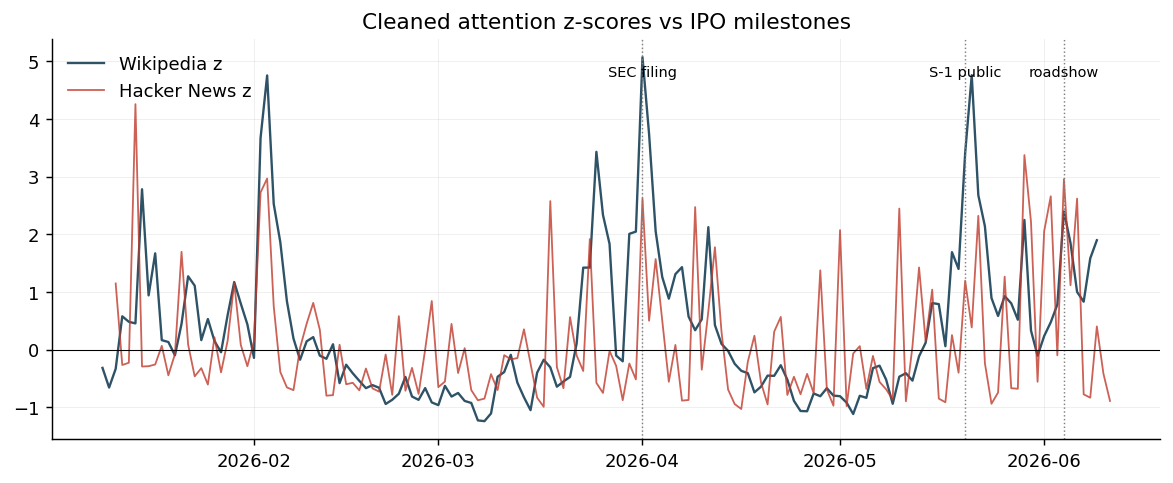

In [7]:
wiki_z = zscore(clean_series(pageviews("SpaceX", days=180))).dropna()
hn_z = zscore(clean_series(daily_attention("spacex", days=180)["points"].astype(float))).dropna()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wiki_z.index, wiki_z.values, lw=1.3, label="Wikipedia z")
ax.plot(hn_z.index, hn_z.values, lw=1.0, alpha=0.8, label="Hacker News z")
for d, lbl in [("2026-04-01", "SEC filing"), ("2026-05-20", "S-1 public"), ("2026-06-04", "roadshow")]:
    ax.axvline(pd.Timestamp(d), color="gray", lw=0.8, ls=":")
    ax.annotate(lbl, (pd.Timestamp(d), ax.get_ylim()[1]*0.88), fontsize=8, ha="center")
ax.axhline(0, color="black", lw=0.6); ax.legend(loc="upper left")
ax.set_title("Cleaned attention z-scores vs IPO milestones")
plt.show()

## 5. Correlations: structure (2y) vs current regime (EWMA)

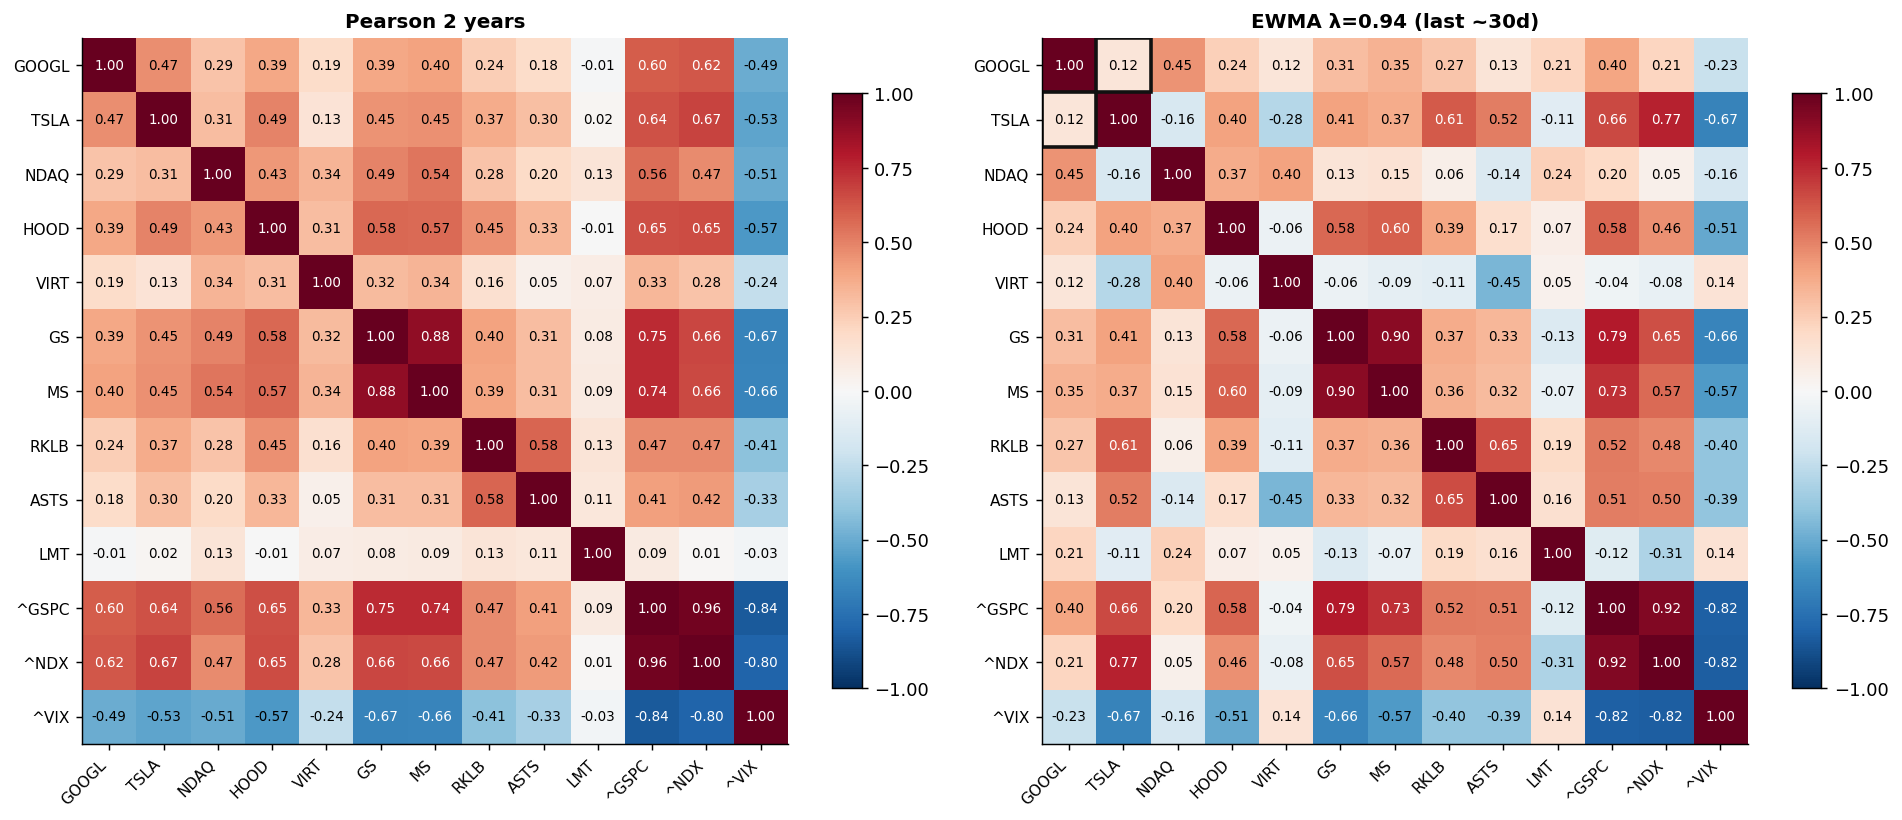

,vol_annua,beta_vs_SP500,max_drawdown,ret_tot_periodo
GOOGL,0.3047,1.1225,-0.2981,1.0783
TSLA,0.6070,2.3689,-0.5377,1.3244
NDAQ,0.2425,0.8241,-0.2176,0.5216
HOOD,0.7184,2.8465,-0.5726,2.6077
VIRT,0.3345,0.6733,-0.2783,1.3947
GS,0.3130,1.4254,-0.3090,1.4194
MS,0.3028,1.3740,-0.2924,1.3285
RKLB,0.8977,2.5859,-0.4815,22.6827
ASTS,1.0674,2.6642,-0.5409,7.9878
LMT,0.2540,0.1440,-0.3179,0.2074


In [8]:
from src.risk.metrics import log_returns, corr_matrix, ewma_corr, summary_table
rets = log_returns(prices.dropna())
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
corr_heatmap(axes[0], corr_matrix(rets), "Pearson 2 years")
corr_heatmap(axes[1], ewma_corr(rets), "EWMA λ=0.94 (last ~30d)", highlight=("GOOGL", "TSLA"))
fig.tight_layout(); plt.show()
summary_table(prices.dropna())

## 6. VERTICAL VALIDATION — are the fat tails in the data?

The MC assumes Student-t with dof=4. Here we fit the t on real returns of the volatility proxy (TSLA: same key-man risk as SPCX) and compare with the Normal. If the Normal won, the MC would need rework.

TSLA: excess kurtosis 3.9 | fitted t-dof 5.3 | loglik t 947 vs norm 921 -> Student-t JUSTIFIED


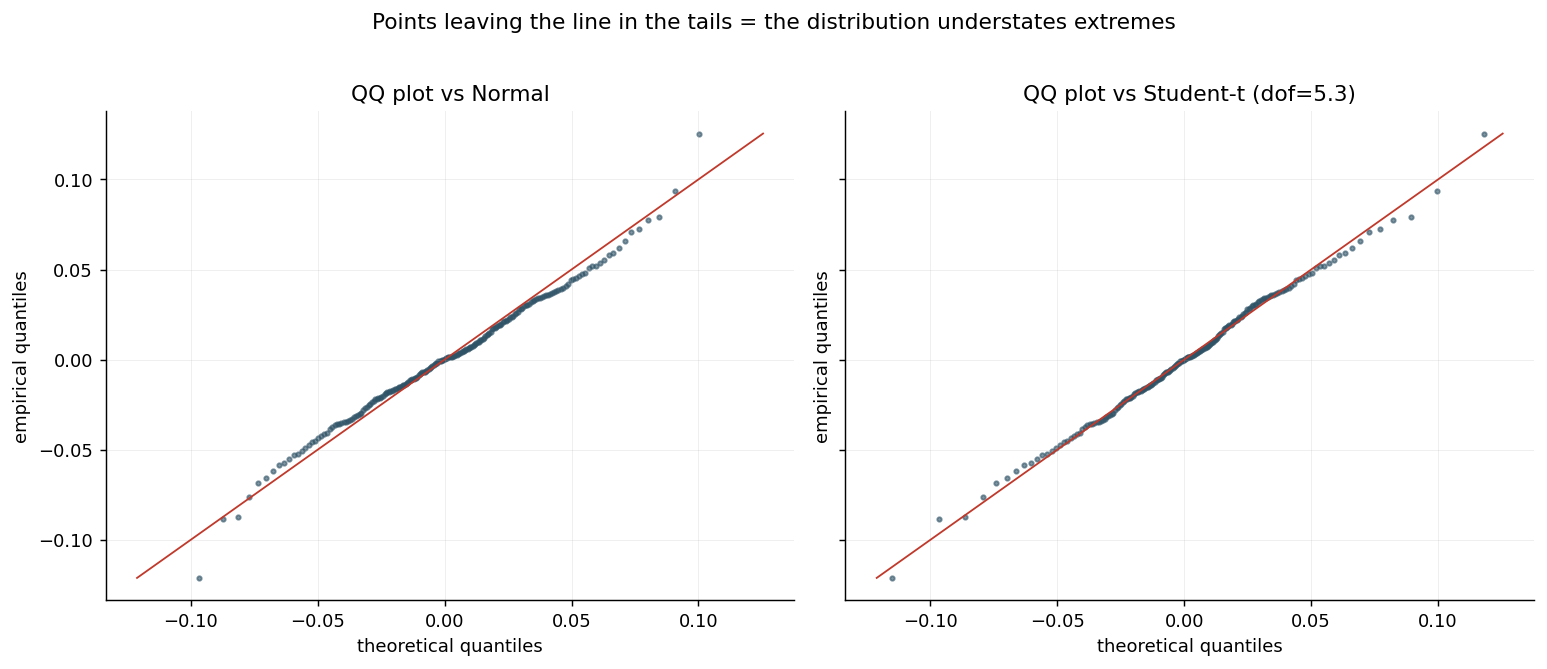

In [9]:
from scipy import stats
from src.research.dist_validation import fit_distributions, qq_data
f = fit_distributions("TSLA", "2y")
print(f"TSLA: excess kurtosis {f['excess_kurtosis']:.1f} | fitted t-dof {f['t_dof']:.1f} | "
      f"loglik t {f['loglik_t']:.0f} vs norm {f['loglik_norm']:.0f} -> {'Student-t JUSTIFIED' if f['t_wins'] else 'REWORK THE MC'}")
r = f["returns"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (dist, params, name) in zip(axes, [(stats.norm, stats.norm.fit(r), "Normal"), (stats.t, stats.t.fit(r), f"Student-t (dof={f['t_dof']:.1f})")]):
    th, emp = qq_data(r, dist, *params)
    ax.scatter(th, emp, s=6, alpha=0.6)
    lim = [min(th.min(), emp.min()), max(th.max(), emp.max())]
    ax.plot(lim, lim, color=PALETTE[1], lw=1)
    ax.set_title(f"QQ plot vs {name}")
    ax.set_xlabel("theoretical quantiles"); ax.set_ylabel("empirical quantiles")
fig.suptitle("Points leaving the line in the tails = the distribution understates extremes", y=1.02)
fig.tight_layout(); plt.show()

## 7. HORIZONTAL VALIDATION — event study on historical lockups

UBER (Nov 2019), RIVN (May 2022), META (Nov 2012), SNAP (Jul 2017): price normalized to 100 at lockup expiry (T0), from T-30 to T+60 sessions.

**The finding that corrects the naive thesis**: the average drop happens BEFORE expiry (anticipation), and T0 is often a local bottom. The rumor gets sold, the news gets bought.

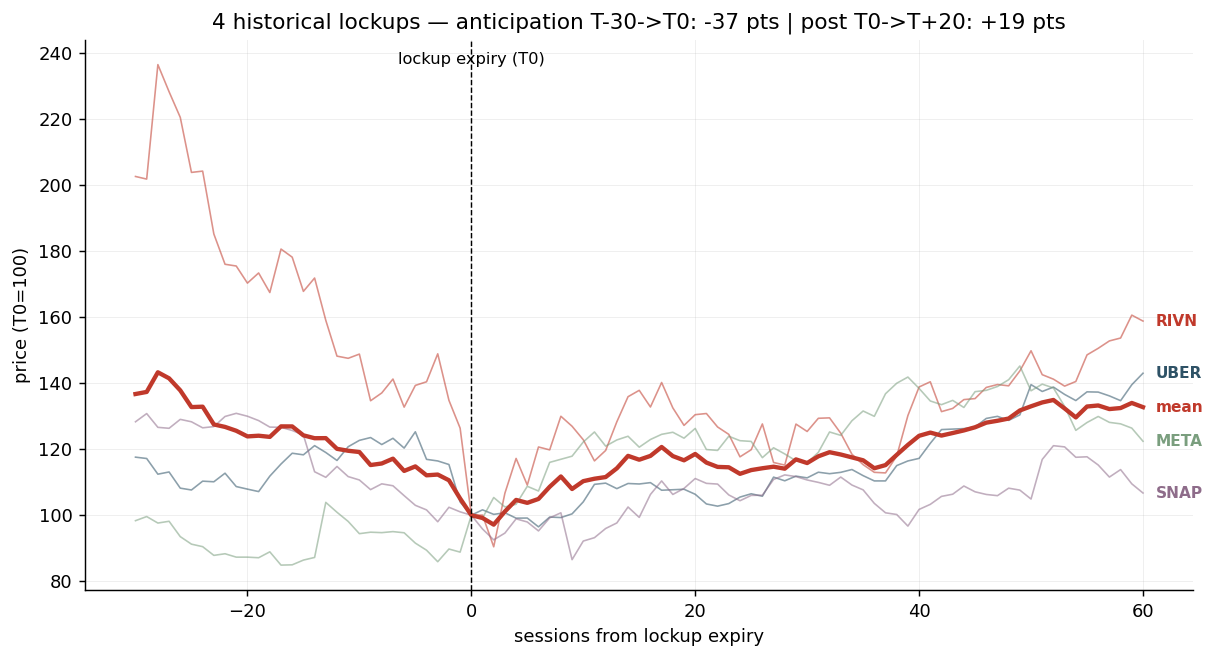

,UBER,RIVN,META,SNAP,mean
-30,117.6,202.6,98.3,128.3,136.7
-20,107.9,170.3,87.3,130.0,123.9
-10,122.7,148.8,94.4,110.7,119.1
0,100.0,100.0,100.0,100.0,100.0
10,104.0,122.9,122.2,92.2,110.3
20,106.3,130.5,126.3,111.1,118.6
40,117.2,138.8,138.4,101.8,124.1
60,143.0,158.8,122.4,106.7,132.7


In [10]:
from src.research.lockup_study import lockup_panel, LOCKUP_EVENTS
panel = lockup_panel()
fig, ax = plt.subplots(figsize=(11, 5.5))
for c in [c for c in panel.columns if c != "mean"]:
    ax.plot(panel.index, panel[c], lw=0.9, alpha=0.55)
ax.plot(panel.index, panel["mean"], lw=2.4, color=PALETTE[1])
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.annotate("lockup expiry (T0)", (0, ax.get_ylim()[1]*0.97), fontsize=9, ha="center")
direct_label_lines(ax, panel)
ant = panel["mean"].loc[0] - panel["mean"].loc[-30]
post = panel["mean"].loc[20] - panel["mean"].loc[0]
ax.set_title(f"4 historical lockups — anticipation T-30->T0: {ant:+.0f} pts | post T0->T+20: {post:+.0f} pts")
ax.set_xlabel("sessions from lockup expiry"); ax.set_ylabel("price (T0=100)")
plt.show()
panel.loc[[-30, -20, -10, 0, 10, 20, 40, 60]].round(1)

**Operational implication (adopted in the timeline)**: open the spread in July (already planned) and close it AT the insider unlock — within T+5, without waiting for a continuation that historically does not come. Caveat: SPCX's unlock is staggered and accelerated; the anticipation phase may start as early as July.

## 8. Plan Monte Carlo + sensitivity

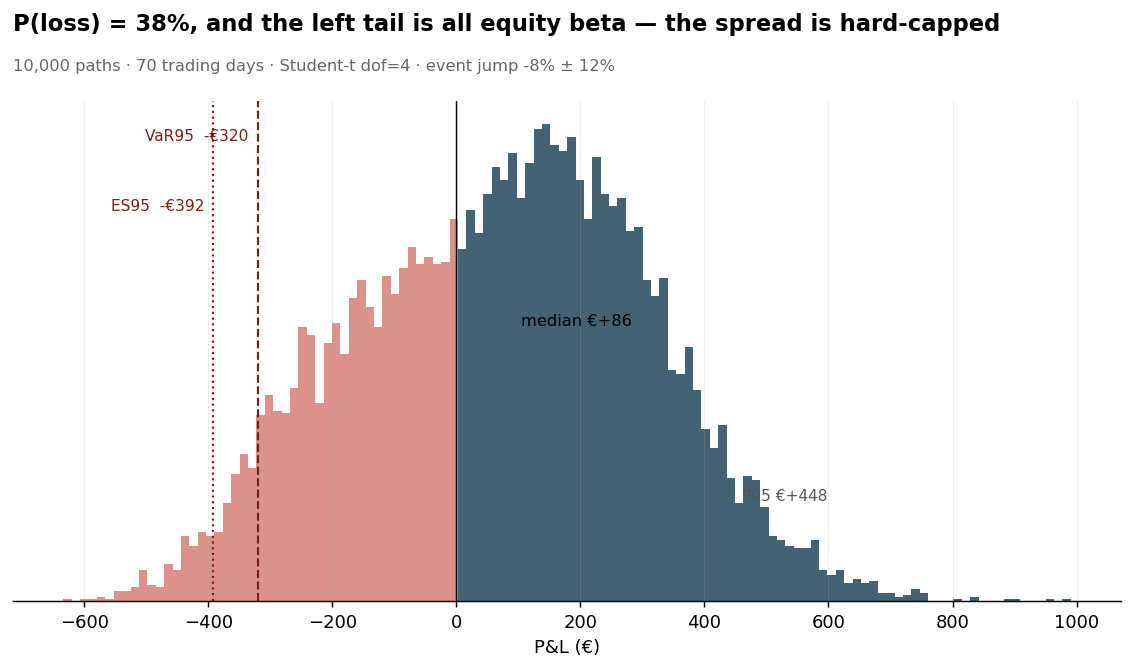

,total mean,spread-only mean,P(loss),ES95
jump,,,,
-20%,127,107,28%,347
-15%,102,83,32%,367
-10%,78,58,37%,385
-8%,68,48,39%,393
-5%,53,33,42%,401
+0%,31,11,45%,414
+5%,9,-11,50%,425


In [11]:
from src.risk.montecarlo import McConfig, SpreadPosition, simulate, report
from dataclasses import replace
cfg, spread = McConfig(), SpreadPosition()
res = simulate(cfg, spread)
rep = report(res)
assert res["pnl_spread_eur"].min() >= -(spread.debit*100*spread.contracts/1.08) - 1e-6, "HARD CAP VIOLATED"
fig, ax = plt.subplots(figsize=(11, 5))
pnl_distribution(ax, res["pnl_total_eur"], rep["VaR95"], rep["ES95"],
                 f"P(loss) = {rep['p_loss']:.0%}, and the left tail is all equity beta — the spread is hard-capped",
                 f"10,000 paths · 70 trading days · Student-t dof=4 · event jump {cfg.jump_mean:+.0%} ± {cfg.jump_std:.0%}")
plt.show()
rows = []
for jm in [-0.20, -0.15, -0.10, -0.08, -0.05, 0.0, 0.05]:
    res2 = simulate(replace(cfg, jump_mean=jm, seed=11), spread)
    r2 = report(res2)
    rows.append({"jump": f"{jm:+.0%}", "total mean": round(r2["mean"]),
                 "spread-only mean": round(float(res2["pnl_spread_eur"].mean())),
                 "P(loss)": f"{r2['p_loss']:.0%}", "ES95": round(r2["ES95"])})
pd.DataFrame(rows).set_index("jump")

## 9. Master report verdict

1. **Pipeline**: 6/6 connectors alive, quality gate clean across the universe (sections 1-2).
2. **Signals graded**: trade only on score ≥ 7 sources (prices/IV, Form 4, Polymarket, EDGAR); attention data is context, Reddit is contrarian-only (section 4).
3. **Model validated**: empirical fat tails (kurtosis ~4, fitted t-dof ~5) justify the Student-t MC (section 6).
4. **Thesis refined by history**: lockup drops are anticipation-driven (-37 pts avg T-30->T0 across 4 precedents); exit by T+5 after the unlock (section 7).
5. **Plan risk**: the spread hard cap holds on every path; the left tail is entirely equity beta. Judge the trade on the spread-only sensitivity line — the total is padded by the GOOGL drift assumption (section 8).
6. **Post-IPO updates** (~Jun 22): real `spcx_s0`, `spcx_vol` from listed-option IV, real `debit`; from August, monitor `form4_watch()`.

Capital-tier playbooks (from thousands to millions) live in `docs/07-capital-tiers.md`.